# 🍽️ **GoodSpot — Restaurant Recommendation System**

> **A Hybrid ML-powered engine** that blends Content-Based Filtering (TF-IDF),  
> Collaborative Filtering (SVD), and dynamic alpha blending to deliver  
> personalised restaurant recommendations for 9,249 Bengaluru restaurants.

---

| 🔗 **Live Demo** | 🔗 **Backend API** | 🔗 **Repository** |
|:---:|:---:|:---:|
| [goodspot-frontend.vercel.app](https://goodspot-frontend.vercel.app) | [goodspot-backend.onrender.com/docs](https://goodspot-backend.onrender.com/docs) | [GitHub](https://github.com/prxth4m/Restaurant-Recommendation-System) |

**Tech Stack:** FastAPI · Next.js · MongoDB Atlas · scikit-learn · Surprise · Render · Vercel  
**Author:** Pratham Kumar

---
## 📑 **Table of Contents**

| # | Section | Description |
|:---:|:---|:---|
| 0 | [🏗️ System Architecture](#arch) | End-to-end pipeline overview |
| 1 | [📦 Dataset Setup](#dataset) | Loading & inspecting the Zomato Bengaluru dataset |
| 2 | [📊 Exploratory Data Analysis](#eda) | Visual distributions — cuisines, locations, ratings, prices |
| 3 | [🔤 Text Preprocessing & Feature Engineering](#preprocess) | Combined features column, TF-IDF vectorisation |
| 4 | [📐 Algorithm 1 — Content-Based Filtering (CBF)](#cbf) | TF-IDF + cosine similarity (computed on-the-fly) |
| 5 | [🤝 Algorithm 2 — Collaborative Filtering (CF)](#cf) | SVD matrix factorisation on user–restaurant ratings |
| 6 | [⚡ Algorithm 3 — Hybrid Blending](#hybrid) | Dynamic alpha ramp: α(n) blends CBF ↔ CF |
| 7 | [🏅 Scoring Breakdown](#scoring) | Popularity score, preference match, hybrid formula |
| 8 | [👥 Group Recommendations](#group) | Multi-user aggregation with coverage weighting |
| 9 | [🔄 Live SVD Retrain Pipeline](#retrain) | MongoDB → merge → retrain → hot-reload |
| 10 | [☁️ Deployment Architecture](#deploy) | Render (backend) + Vercel (frontend) + MongoDB Atlas |
| 11 | [📈 Evaluation & Visualisation](#eval) | Score distributions, technique comparison |
| 12 | [🎮 Interactive Playground](#playground) | Try your own preferences and see live results |

---

## 0. 🏗️ System Architecture

```
┌─────────────────────────────────────────────────────────────────────────────┐
│                        GoodSpot — System Architecture                       │
├─────────────────────────────────────────────────────────────────────────────┤
│                                                                             │
│  ┌──────────────┐     ┌──────────────────────┐     ┌────────────────────┐  │
│  │   Zomato CSV  │────▶│  Data Preprocessing  │────▶│  zomato_clean.     │  │
│  │  (51K raw)    │     │  • Clean text         │     │  parquet (9,249)   │  │
│  └──────────────┘     │  • Encode categories  │     └─────────┬──────────┘  │
│                       │  • Build features     │               │             │
│                       └──────────────────────┘               │             │
│                                                               ▼             │
│  ┌────────────────────────────────────────────────────────────────────────┐ │
│  │                         ML Pipeline                                    │ │
│  │                                                                        │ │
│  │  ┌─────────────────┐  ┌─────────────────┐  ┌──────────────────────┐  │ │
│  │  │  TF-IDF Matrix  │  │   SVD Model      │  │ User Interactions   │  │ │
│  │  │  (9249 × 245)   │  │  (50 factors)    │  │  (.parquet + Mongo) │  │ │
│  │  │  ~0.5 MB sparse │  │  ~1.9 MB         │  │  11,366+ ratings    │  │ │
│  │  └────────┬────────┘  └────────┬─────────┘  └──────────┬───────────┘  │ │
│  │           │                    │                       │              │ │
│  │           ▼                    ▼                       ▼              │ │
│  │     ┌──────────┐        ┌──────────┐          ┌──────────────┐       │ │
│  │     │   CBF    │        │    CF    │          │    Hybrid    │       │ │
│  │     │ cosine   │        │  SVD     │          │ (1-α)·CBF   │       │ │
│  │     │ sim on   │        │  predict │          │  + α·CF     │       │ │
│  │     │ the fly  │        │          │          │  α = f(n)   │       │ │
│  │     └──────────┘        └──────────┘          └──────────────┘       │ │
│  └────────────────────────────────────────────────────────────────────────┘ │
│                                    │                                        │
│                                    ▼                                        │
│  ┌─────────────────┐    ┌──────────────────┐    ┌─────────────────────┐    │
│  │   FastAPI        │    │   MongoDB Atlas   │    │   Next.js Frontend  │   │
│  │   (Render)       │◀──▶│   (Users, Auth,   │    │   (Vercel)          │   │
│  │   Port 10000     │    │    Interactions)   │    │   SSR + CSR         │   │
│  └─────────────────┘    └──────────────────┘    └─────────────────────┘    │
│          ▲                                                ▲                 │
│          └────────────────── REST API ─────────────────────┘                │
└─────────────────────────────────────────────────────────────────────────────┘
```

### Key Design Decisions
- **Sparse TF-IDF (0.5 MB)** replaces a 342 MB dense cosine-sim matrix → fits in Render's 512 MB free tier  
- **On-the-fly similarity** via `linear_kernel` computes only the ~9,249 scores needed per query (~3 ms)  
- **Dynamic alpha** ramps CF weight as users accumulate interactions — cold-start safe  
- **SVD retrains on every startup** by merging offline parquet + live MongoDB ratings

---
## 1. 📦 Dataset Setup

The dataset is a cleaned subset of the **Zomato Bengaluru Restaurants** dataset:  
- **9,249 restaurants** after deduplication and quality filtering  
- **11,366+ user–restaurant ratings** for collaborative filtering  

We load from `.parquet` (columnar, compressed) instead of CSV for ~3x faster I/O.

In [1]:
# ── 1.1 Install dependencies ──────────────────────────────
!pip install pandas numpy scikit-learn scikit-surprise matplotlib seaborn joblib pyarrow -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.4/154.4 kB 4.7 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [2]:
# ── 1.2 Clone the repository ──────────────────────────────
!git clone https://github.com/prxth4m/Restaurant-Recommendation-System.git
import os
os.chdir('Restaurant-Recommendation-System')
print('✅ Repository cloned and ready.')

Cloning into 'Restaurant-Recommendation-System'...
remote: Enumerating objects: 211, done.
remote: Counting objects: 100% (211/211), done.
remote: Compressing objects: 100% (109/109), done.
remote: Total 211 (delta 82), reused 207 (delta 78), pack-reused 0 (from 0)
Receiving objects: 100% (211/211), 173.83 KiB | 5.61 MiB/s, done.
Resolving deltas: 100% (82/82), done.
✅ Repository cloned and ready.


In [3]:
# ── 1.3 Load the cleaned dataset ─────────────────────────
import pandas as pd
import numpy as np

MODELS_DIR = 'backend/models'

df = pd.read_parquet(os.path.join(MODELS_DIR, 'zomato_clean.parquet'))
df['restaurant_id'] = df.index

print(f'🍽️  Loaded {len(df):,} restaurants')
print(f'📐 Shape: {df.shape}')
print(f'📊 Columns: {list(df.columns)}')
df.head()

🍽️  Loaded 9,249 restaurants
📐 Shape: (9249, 13)
📊 Columns: ['restaurant_id', 'name', 'cuisines', 'rest_type', 'listed_in(type)', 'location', 'listed_in(city)', 'rate', 'votes', 'cost_for_two', 'online_order', 'book_table', 'combined_features']


,restaurant_id,name,cuisines,rest_type,listed_in(type),location,listed_in(city),rate,votes,cost_for_two,online_order,book_table,combined_features
0,0,Byg Brewski Brewing Company,"Continental, North Indian, Italian, South Indi...",Microbrewery,Delivery,Sarjapur Road,Sarjapur Road,4.9,16832,1600,1,1,continental north indian italian south indian ...
1,1,Toit,"Italian, American, Pizza",Microbrewery,Dine-out,Indiranagar,Indiranagar,4.7,14956,1500,0,0,italian american pizza microbrewery dine indir...
2,2,Truffles,"Cafe, American, Burger, Steak","Cafe, Casual Dining",Dine-out,Koramangala 5th Block,Koramangala 7th Block,4.7,14726,900,0,0,cafe american burger steak cafe casual dining ...
3,3,AB's - Absolute Barbecues,"European, Mediterranean, North Indian, BBQ",Casual Dining,Buffet,Marathahalli,Marathahalli,4.8,12121,1600,0,1,european mediterranean north indian bbq casual...
4,4,The Black Pearl,"North Indian, European, Mediterranean","Casual Dining, Bar",Pubs and bars,Koramangala 5th Block,Koramangala 7th Block,4.7,10550,1400,0,1,north indian european mediterranean casual din...


In [4]:
# ── 1.4 Basic statistics ─────────────────────────────────
print('\n── Numeric Summary ──')
print(df[['rate', 'votes', 'cost_for_two']].describe().round(2))

print(f'\n── Missing Values ──')
print(df.isnull().sum()[df.isnull().sum() > 0])

print(f'\n── Unique Locations: {df["location"].nunique()}')
print(f'── Unique Cuisine Combos: {df["cuisines"].nunique()}')


── Numeric Summary ──
          rate     votes  cost_for_two
count  9249.00   9249.00       9249.00
mean      3.63    246.18        537.62
std       0.43    684.95        426.77
min       1.80      0.00         40.00
25%       3.30     17.00        300.00
50%       3.70     54.00        400.00
75%       3.90    194.00        600.00
max       4.90  16832.00       6000.00

── Missing Values ──
Series([], dtype: int64)

── Unique Locations: 92
── Unique Cuisine Combos: 2280


---
## 2. 📊 Exploratory Data Analysis

Visual exploration of the dataset across 6 key dimensions:  
ratings, votes, prices, cuisines, locations, and online ordering behaviour.

/tmp/ipykernel_6710/1706423731.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='order_label', y='rate', ax=axes[1, 2], palette=['#FC8019', '#2E86AB'])
/tmp/ipykernel_6710/1706423731.py:44: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6710/1706423731.py:44: UserWarning: Glyph 128176 (\N{MONEY BAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6710/1706423731.py:44: UserWarning: Glyph 128499 (\N{BALLOT BOX WITH BALLOT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6710/1706423731.py:44: UserWarning: Glyph 127829 (\N{SLICE OF PIZZA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6710/1706423731.py:44: UserWarning: Glyph 128205 (\N{ROUND PUSHPIN}) missing from font(s) DejaVu Sans.

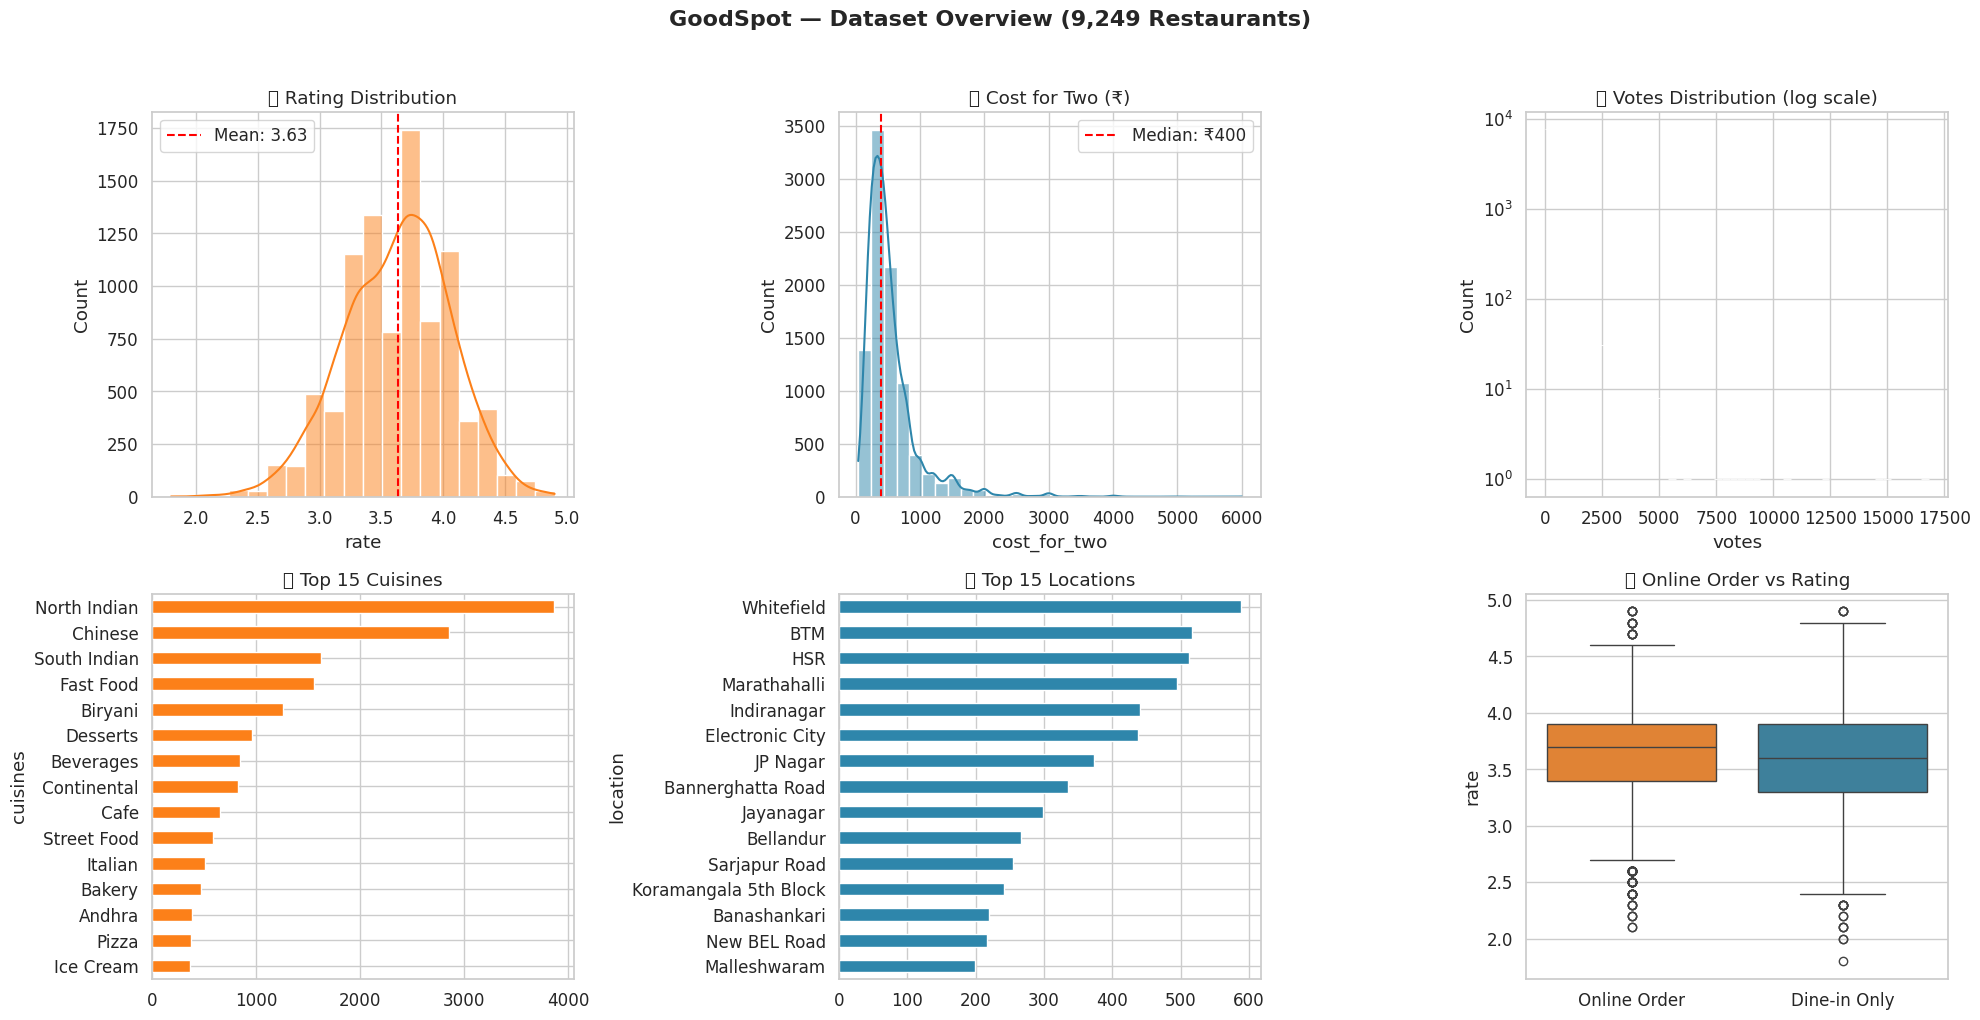

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
fig, axes = plt.subplots(2, 3, figsize=(20, 10))
fig.suptitle('GoodSpot — Dataset Overview (9,249 Restaurants)', fontsize=16, fontweight='bold', y=1.02)

# 1. Rating distribution
sns.histplot(df['rate'].dropna(), bins=20, kde=True, ax=axes[0, 0], color='#FC8019')
axes[0, 0].set_title('⭐ Rating Distribution')
axes[0, 0].axvline(df['rate'].mean(), color='red', linestyle='--', label=f'Mean: {df["rate"].mean():.2f}')
axes[0, 0].legend()

# 2. Price distribution
sns.histplot(df['cost_for_two'].dropna(), bins=30, kde=True, ax=axes[0, 1], color='#2E86AB')
axes[0, 1].set_title('💰 Cost for Two (₹)')
axes[0, 1].axvline(df['cost_for_two'].median(), color='red', linestyle='--', label=f'Median: ₹{df["cost_for_two"].median():.0f}')
axes[0, 1].legend()

# 3. Votes distribution (log scale)
sns.histplot(df['votes'].dropna(), bins=50, ax=axes[0, 2], color='#A23B72', log_scale=(False, True))
axes[0, 2].set_title('🗳️ Votes Distribution (log scale)')

# 4. Top 15 cuisines
all_cuisines = df['cuisines'].dropna().str.split(',').explode().str.strip()
top_cuisines = all_cuisines.value_counts().head(15)
top_cuisines.plot(kind='barh', ax=axes[1, 0], color='#FC8019')
axes[1, 0].set_title('🍕 Top 15 Cuisines')
axes[1, 0].invert_yaxis()

# 5. Top 15 locations
top_locs = df['location'].value_counts().head(15)
top_locs.plot(kind='barh', ax=axes[1, 1], color='#2E86AB')
axes[1, 1].set_title('📍 Top 15 Locations')
axes[1, 1].invert_yaxis()

# 6. Online Order vs Rating
order_labels = {1: 'Online Order', 0: 'Dine-in Only'}
df['order_label'] = df['online_order'].map(order_labels)
sns.boxplot(data=df, x='order_label', y='rate', ax=axes[1, 2], palette=['#FC8019', '#2E86AB'])
axes[1, 2].set_title('🛒 Online Order vs Rating')
axes[1, 2].set_xlabel('')

plt.tight_layout()
plt.show()

# Clean up temp column
df.drop(columns=['order_label'], inplace=True, errors='ignore')

---
## 3. 🔤 Text Preprocessing & Feature Engineering

For Content-Based Filtering, we build a **combined text feature** for each restaurant by concatenating:

```
combined_features = cuisines + location + rest_type + rate_bucket + price_bucket
```

This single text column is then transformed into a **TF-IDF sparse matrix** (Term Frequency–Inverse Document Frequency).

### Why TF-IDF?
- Captures **importance** of each term relative to the entire corpus
- A restaurant serving "North Indian" in a sea of Chinese restaurants gets a **higher weight** for that term
- Sparse representation = **0.5 MB** vs 342 MB for a dense cosine similarity matrix

In [6]:
# ── 3.1 Inspect combined_features ─────────────────────────
print('Sample combined_features:')
for i in range(5):
    print(f'  [{i}] {df["name"].iloc[i]}')
    print(f'       → {df["combined_features"].iloc[i][:120]}...')
    print()

Sample combined_features:
  [0] Byg Brewski Brewing Company
       → continental north indian italian south indian finger food microbrewery delivery sarjapur road...

  [1] Toit
       → italian american pizza microbrewery dine indiranagar...

  [2] Truffles
       → cafe american burger steak cafe casual dining dine koramangala th block...

  [3] AB's - Absolute Barbecues
       → european mediterranean north indian bbq casual dining buffet marathahalli...

  [4] The Black Pearl
       → north indian european mediterranean casual dining bar pubs bars koramangala th block...



In [7]:
# ── 3.2 Build TF-IDF Matrix ──────────────────────────────
import joblib

tfidf_vectorizer = joblib.load(os.path.join(MODELS_DIR, 'tfidf_vectoriser.pkl'))
tfidf_matrix = tfidf_vectorizer.transform(df['combined_features'].fillna(''))

print(f'✅ TF-IDF Matrix:')
print(f'   Shape         : {tfidf_matrix.shape} (restaurants × features)')
print(f'   Non-zero vals : {tfidf_matrix.nnz:,}')
print(f'   Sparsity      : {1 - tfidf_matrix.nnz / (tfidf_matrix.shape[0] * tfidf_matrix.shape[1]):.4%}')
print(f'   Memory (sparse): {tfidf_matrix.data.nbytes / 1024**2:.2f} MB')
print(f'   Memory (dense) : {tfidf_matrix.shape[0] * tfidf_matrix.shape[1] * 8 / 1024**2:.1f} MB (avoided!)')

# Show top features
feature_names = tfidf_vectorizer.get_feature_names_out()
print(f'\n   Top 20 features: {list(feature_names[:20])}')

✅ TF-IDF Matrix:
   Shape         : (9249, 245) (restaurants × features)
   Non-zero vals : 69,685
   Sparsity      : 96.9248%
   Memory (sparse): 0.53 MB
   Memory (dense) : 17.3 MB (avoided!)

   Top 20 features: ['afghan', 'african', 'airport', 'american', 'andhra', 'arabian', 'asian', 'assamese', 'australian', 'awadhi', 'bakery', 'banashankari', 'banaswadi', 'bangalore', 'bannerghatta', 'bar', 'bars', 'basavanagudi', 'basaveshwara', 'bbq']


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator TfidfTransformer from version 1.7.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator TfidfVectorizer from version 1.7.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


---
## 4. 📐 Algorithm 1 — Content-Based Filtering (CBF)

### Mathematical Foundation

Given a query restaurant **q**, we compute its similarity to every other restaurant using **cosine similarity** on TF-IDF vectors:

$$
\text{sim}(q, r) = \frac{\vec{v}_q \cdot \vec{v}_r}{\|\vec{v}_q\| \cdot \|\vec{v}_r\|}
$$

Since TF-IDF vectors are already L2-normalised, this simplifies to a **dot product** (linear kernel):

$$
\text{sim}(q, r) = \vec{v}_q \cdot \vec{v}_r = \texttt{linear\_kernel}(\text{tfidf}[q], \text{tfidf})
$$

### Final CBF Score
$$
\text{CBF}_{score} = 0.7 \times \text{cosine\_sim} + 0.3 \times \text{popularity\_score}
$$

Where popularity is:
$$
\text{pop}(r) = 0.6 \times \frac{\text{rating}}{5.0} + 0.4 \times \frac{\ln(1 + \text{votes})}{\ln(1 + \text{max\_votes})}
$$

### Memory Optimisation
| Approach | Storage | RAM at Runtime |
|:---|:---:|:---:|
| **Old:** Pre-computed dense matrix | 342 MB `.npy` file | ~844 MB |
| **New:** On-the-fly `linear_kernel` | 8 KB vectorizer | ~215 MB |

The new approach computes only the **9,249 scores** needed per query in **~3 ms**.

In [8]:
# ── 4.1 CBF Recommendation Demo ──────────────────────────
from sklearn.metrics.pairwise import linear_kernel
import json
import difflib
import time

# Load name index
with open(os.path.join(MODELS_DIR, 'restaurant_names.json')) as f:
    names_data = json.load(f)
    name_to_idx = names_data['name_to_idx']
    all_names_lower = names_data['all_names_lower']

max_log_votes = np.log1p(df['votes'].max())

def popularity_score(row):
    rating = float(row.get('rate', 0) or 0)
    votes = float(row.get('votes', 0) or 0)
    log_v = np.log1p(votes) / max_log_votes if max_log_votes > 0 else 0
    return round(0.6 * (rating / 5.0) + 0.4 * log_v, 4)

def cbf_recommend(restaurant_name, top_n=10):
    """Content-Based Filtering with on-the-fly cosine similarity."""
    matches = difflib.get_close_matches(restaurant_name.lower(), all_names_lower, n=1, cutoff=0.4)
    if not matches:
        print(f'❌ No match found for "{restaurant_name}"')
        return pd.DataFrame()

    idx = name_to_idx[matches[0]]
    matched_name = df.iloc[idx]['name']
    print(f'🔍 Matched: "{restaurant_name}" → "{matched_name}" (idx={idx})')

    # On-the-fly cosine similarity
    start = time.time()
    sim_row = linear_kernel(tfidf_matrix[idx:idx+1], tfidf_matrix).flatten()
    elapsed = (time.time() - start) * 1000

    sim_scores = sorted(enumerate(sim_row), key=lambda x: x[1], reverse=True)
    sim_scores = [(i, s) for i, s in sim_scores if i != idx][:top_n]

    result_df = df.iloc[[i for i, _ in sim_scores]].copy()
    result_df['cosine_sim'] = [s for _, s in sim_scores]
    result_df['pop_score'] = result_df.apply(popularity_score, axis=1)
    result_df['cbf_score'] = result_df['cosine_sim'] * 0.7 + result_df['pop_score'] * 0.3

    print(f'⏱️  Computed {len(sim_row):,} similarities in {elapsed:.1f} ms\n')
    return result_df[['name', 'cuisines', 'location', 'rate', 'votes', 'cost_for_two',
                      'cosine_sim', 'pop_score', 'cbf_score']].round(4)

# Demo
cbf_recommend('Jalsa', top_n=10)

🔍 Matched: "Jalsa" → "Jalsa" (idx=619)
⏱️  Computed 9,249 similarities in 6.7 ms



,name,cuisines,location,rate,votes,cost_for_two,cosine_sim,pop_score,cbf_score
5456,Food Box Cafe,"Mughlai, North Indian, Chinese",Banashankari,3.6,36,500,1.0000,0.5804,0.8741
617,1947,"North Indian, Chinese",Banashankari,4.0,808,850,0.8467,0.7552,0.8192
814,Hara Fine Dine,"North Indian, Chinese",Banashankari,4.0,634,800,0.8467,0.7453,0.8163
3139,Sri Krishna Sagar,"North Indian, Chinese",Banashankari,3.2,119,400,0.8467,0.5808,0.7669
4406,J Spice,"North Indian, Chinese",Banashankari,3.8,59,750,0.8467,0.6243,0.7800
5117,Vaishali Deluxe,"North Indian, Chinese",Banashankari,3.8,42,700,0.8467,0.6106,0.7758
5178,New Imperial Restaurant,"North Indian, Chinese",Banashankari,3.7,41,450,0.8467,0.5976,0.7719
6199,Sri Yaksha Shiv Sagar,"North Indian, Chinese",Banashankari,3.6,24,600,0.8467,0.5643,0.7620
1724,Nandhini Deluxe,North Indian,Banashankari,2.6,283,600,0.8041,0.5442,0.7262
2638,Green Gardenia,"North Indian, Chinese",Banashankari,3.8,160,700,0.7871,0.6649,0.7504


In [9]:
# ── 4.2 CBF with Filters ─────────────────────────────────
def cbf_recommend_filtered(restaurant_name, cuisines=None, area=None, price_max=None, top_n=10):
    """CBF with optional cuisine/area/price filters."""
    matches = difflib.get_close_matches(restaurant_name.lower(), all_names_lower, n=1, cutoff=0.4)
    if not matches:
        return pd.DataFrame()

    idx = name_to_idx[matches[0]]

    # Apply filters
    filtered = df.copy()
    if cuisines:
        pattern = '|'.join([c.lower() for c in cuisines])
        filtered = filtered[filtered['cuisines'].str.lower().str.contains(pattern, na=False)]
    if area:
        filtered = filtered[filtered['location'].str.lower().str.contains(area.lower(), na=False)]
    if price_max:
        filtered = filtered[filtered['cost_for_two'] <= price_max]

    filtered_indices = set(filtered.index.tolist())

    sim_row = linear_kernel(tfidf_matrix[idx:idx+1], tfidf_matrix).flatten()
    sim_scores = sorted(enumerate(sim_row), key=lambda x: x[1], reverse=True)
    sim_scores = [(i, s) for i, s in sim_scores if i in filtered_indices and i != idx][:top_n]

    result_df = df.iloc[[i for i, _ in sim_scores]].copy()
    result_df['cbf_score'] = [s for _, s in sim_scores]
    return result_df[['name', 'cuisines', 'location', 'rate', 'cost_for_two', 'cbf_score']].round(4)

print('filter: cuisines=["North Indian"], area="Koramangala", price_max=800')
cbf_recommend_filtered('Jalsa', cuisines=['North Indian'], area='Koramangala', price_max=800)

filter: cuisines=["North Indian"], area="Koramangala", price_max=800


,name,cuisines,location,rate,cost_for_two,cbf_score
19,Empire Restaurant,"North Indian, Mughlai, South Indian, Chinese",Koramangala 5th Block,4.1,750,0.5872
365,Bathinda Junction,"North Indian, Mughlai",Koramangala 5th Block,4.1,600,0.5559
1969,Little Lucknow,"Mughlai, North Indian",Koramangala 5th Block,4.0,800,0.5559
533,Lazeez,"North Indian, Mughlai, Biryani",Koramangala 5th Block,3.1,600,0.5265
7322,Hotel Parampare,"North Indian, Mughlai, Biryani",Koramangala 7th Block,2.9,600,0.5265
546,Aalishan Restaurant & Caterer,"North Indian, Mughlai",Koramangala 7th Block,3.5,650,0.5066
480,Tandoor Hut,"North Indian, Mughlai, Chinese, Rolls",Koramangala 5th Block,4.1,700,0.4983
1582,Lazeez,"North Indian, Mughlai, Biryani",Koramangala 1st Block,2.4,600,0.4471
7650,Midnight Hunger Solutions 24/7,"North Indian, Mughlai, Chinese",Koramangala 5th Block,3.2,500,0.4120
3106,Eshmeet Da Dhaba,"North Indian, Chinese",Koramangala 6th Block,3.1,500,0.3960


---
## 5. 🤝 Algorithm 2 — Collaborative Filtering (CF)

### Mathematical Foundation — SVD (Singular Value Decomposition)

We factorise the **user–restaurant rating matrix** R into three lower-rank matrices:

$$
R \approx U \Sigma V^T
$$

Using the **Surprise** library's SVD implementation:
- **50 latent factors** (captures dining patterns like "prefers-cheap-North-Indian" or "fine-dining-lover")
- **20 epochs** of Stochastic Gradient Descent (SGD)
- **Rating scale:** 1.0 – 5.0

### Prediction
For a user **u** and restaurant **r**:
$$
\hat{r}_{u,i} = \mu + b_u + b_i + \vec{p}_u \cdot \vec{q}_i
$$

Where:
- $\mu$ = global mean rating
- $b_u$ = user bias ("this user rates generously")
- $b_i$ = item bias ("this restaurant is generally well-rated")
- $\vec{p}_u \cdot \vec{q}_i$ = latent factor dot product

### Cold-Start Handling
If a user has **no** interaction history, CF falls back to **popularity-based** ranking within the filtered set.

In [10]:
# ── 5.1 Load SVD Model & Interactions ─────────────────────
svd_model = joblib.load(os.path.join(MODELS_DIR, 'svd_model.pkl'))
interactions_df = pd.read_parquet(os.path.join(MODELS_DIR, 'user_interactions.parquet'))

print(f'✅ SVD Model loaded ({svd_model.n_factors} factors)')
print(f'📊 Interactions: {len(interactions_df):,} ratings')
print(f'👤 Unique users: {interactions_df["user_id"].nunique()}')
print(f'🍽️  Unique restaurants: {interactions_df["restaurant_id"].nunique()}')
print(f'\n── Rating Distribution ──')
print(interactions_df['rating'].describe().round(2))


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py", line 37, in <module>
    ColabKernelApp.launch_instance()
  File "/usr/local/lib/python3.12/dist-packages/traitlets/config/application.py", line 992, in launch_instance
    app.start()
  File "/usr/local/lib/python3.12/dist-packages/ipykernel/kernelapp.py", line 712, in start
    self.io_loop.start()
  File "/usr/local/lib/python3.12/dist-package

ImportError: numpy.core.multiarray failed to import (auto-generated because you didn't call 'numpy.import_array()' after cimporting numpy; use '<void>numpy._import_array' to disable if you are certain you don't need it).

In [ ]:
# ── 5.2 Visualise Rating Matrix Sparsity ──────────────────
n_users = interactions_df['user_id'].nunique()
n_items = interactions_df['restaurant_id'].nunique()
n_ratings = len(interactions_df)
total_possible = n_users * n_items
sparsity = 1 - (n_ratings / total_possible)

print(f'\n📐 Rating Matrix: {n_users} users × {n_items} restaurants')
print(f'📊 Known ratings: {n_ratings:,} / {total_possible:,} possible')
print(f'🕳️  Sparsity: {sparsity:.4%} (only {(1-sparsity)*100:.4f}% filled)')
print(f'\nThis extreme sparsity is WHY we need SVD — it learns latent patterns')
print(f'from the {n_ratings:,} known ratings to predict the remaining {total_possible - n_ratings:,}.')

In [ ]:
# ── 5.3 CF Recommendation Demo ────────────────────────────
def cf_recommend(user_id, top_n=10):
    """SVD-based Collaborative Filtering."""
    if user_id not in interactions_df['user_id'].values:
        print(f'⚠️ User "{user_id}" not in training data → cold-start fallback (popularity)')
        scored = df.copy()
        scored['pop_score'] = scored.apply(popularity_score, axis=1)
        return scored.nlargest(top_n, 'pop_score')[['name', 'cuisines', 'location', 'rate', 'votes', 'pop_score']]

    # Get restaurants this user has already rated
    seen = set(interactions_df[interactions_df['user_id'] == user_id]['restaurant_id'].tolist())
    unseen = [rid for rid in df['restaurant_id'] if rid not in seen]
    print(f'👤 User "{user_id}": {len(seen)} rated, {len(unseen)} candidates')

    # Predict ratings for unseen restaurants
    predictions = []
    for rid in unseen:
        try:
            pred = svd_model.predict(user_id, str(rid))
            predictions.append((rid, pred.est))
        except:
            predictions.append((rid, 3.5))

    predictions.sort(key=lambda x: x[1], reverse=True)
    top_ids = [rid for rid, _ in predictions[:top_n]]
    score_map = {rid: score for rid, score in predictions[:top_n]}

    result_df = df[df['restaurant_id'].isin(top_ids)].copy()
    result_df['cf_score'] = result_df['restaurant_id'].map(score_map)
    result_df = result_df.sort_values('cf_score', ascending=False)
    return result_df[['name', 'cuisines', 'location', 'rate', 'votes', 'cf_score']].round(4)

# Pick a user with the most interactions
top_user = interactions_df['user_id'].value_counts().index[0]
print(f'\n📌 Demo user: "{top_user}" ({interactions_df["user_id"].value_counts().iloc[0]} ratings)\n')
cf_recommend(top_user)

---
## 6. ⚡ Algorithm 3 — Hybrid Blending

### The Core Formula

$$
\text{Hybrid}_{score}(r) = (1 - \alpha) \times \text{CBF}_{score}(r) + \alpha \times \text{CF}_{score}(r)
$$

### Dynamic Alpha Ramp — `α(n)`

Alpha is **not fixed** — it ramps up as the user accumulates interactions:

| Interaction Count (n) | α Value | Behaviour |
|:---:|:---:|:---|
| 0 | **0.0** | Pure CBF — no CF data yet |
| 1 – 2 | **0.1** | 90% CBF + 10% CF — dipping toes |
| 3 – 9 | **0.4** | 60% CBF + 40% CF — balanced blend |
| 10+ | **0.7** | 30% CBF + 70% CF — trust the user's history |

### Why Dynamic Alpha?
- **Cold-start safe:** New users get content recommendations immediately
- **Progressive personalisation:** As users interact, CF gets more weight
- **No cliff edge:** Smooth transition prevents jarring recommendation shifts

In [ ]:
# ── 6.1 Alpha Ramp Visualisation ─────────────────────────
def get_alpha(n):
    if n == 0: return 0.0
    elif n <= 2: return 0.1
    elif n <= 9: return 0.4
    else: return 0.7

ns = range(0, 25)
alphas = [get_alpha(n) for n in ns]

fig, ax = plt.subplots(figsize=(12, 4))
ax.step(ns, alphas, where='post', linewidth=2.5, color='#FC8019', label='α (CF weight)')
ax.fill_between(ns, alphas, step='post', alpha=0.15, color='#FC8019')
ax.fill_between(ns, [1 - a for a in alphas], step='post', alpha=0.15, color='#2E86AB')
ax.set_xlabel('Number of User Interactions')
ax.set_ylabel('Weight')
ax.set_title('⚡ Dynamic Alpha Ramp — CBF vs CF Weight')
ax.legend(['α = CF Weight', '1 - α = CBF Weight'], loc='center right')
ax.set_ylim(-0.05, 1.05)
ax.axhline(0.5, linestyle=':', color='gray', alpha=0.5)

# Annotate regions
ax.annotate('Pure CBF', xy=(0, 0.05), fontsize=10, fontweight='bold', color='#2E86AB')
ax.annotate('Balanced', xy=(5, 0.45), fontsize=10, fontweight='bold', color='gray')
ax.annotate('CF-Dominant', xy=(15, 0.75), fontsize=10, fontweight='bold', color='#FC8019')
plt.tight_layout()
plt.show()

In [ ]:
# ── 6.2 Hybrid Recommendation Demo ───────────────────────
def hybrid_recommend(user_id=None, restaurant_name=None, top_n=10, alpha=None, live_count=0):
    """Blend CBF + CF with dynamic alpha."""
    if alpha is None:
        alpha = get_alpha(live_count)

    # CBF scores
    cbf_results = cbf_recommend(restaurant_name, top_n=top_n * 2) if restaurant_name else pd.DataFrame()
    cbf_map = dict(zip(cbf_results.index, cbf_results['cbf_score'])) if not cbf_results.empty else {}

    # CF scores
    cf_map = {}
    if user_id and user_id in interactions_df['user_id'].values:
        seen = set(interactions_df[interactions_df['user_id'] == user_id]['restaurant_id'])
        for rid in df['restaurant_id']:
            if rid not in seen:
                try:
                    cf_map[rid] = svd_model.predict(user_id, str(rid)).est
                except:
                    pass

    # Blend
    all_ids = list(set(cbf_map.keys()) | set(cf_map.keys()))
    max_cf = max(cf_map.values(), default=1) or 1

    scored = []
    for rid in all_ids:
        cbf_s = cbf_map.get(rid, 0)
        cf_s = cf_map.get(rid, 0) / max_cf
        hybrid_s = (1 - alpha) * cbf_s + alpha * cf_s
        scored.append((rid, hybrid_s, cbf_s, cf_s / max_cf))

    scored.sort(key=lambda x: x[1], reverse=True)
    top = scored[:top_n]

    result_df = df.iloc[[rid for rid, _, _, _ in top]].copy()
    result_df['hybrid_score'] = [h for _, h, _, _ in top]
    result_df['cbf_component'] = [c for _, _, c, _ in top]
    result_df['cf_component'] = [cf for _, _, _, cf in top]

    print(f'\n⚡ Hybrid (α={alpha}) | CBF weight: {1-alpha:.0%} | CF weight: {alpha:.0%}')
    return result_df[['name', 'cuisines', 'location', 'rate', 'cbf_component',
                      'cf_component', 'hybrid_score']].round(4)

# Demo: user with 5 interactions (α=0.4)
hybrid_recommend(user_id=top_user, restaurant_name='Jalsa', live_count=5)

---
## 7. 🏅 Scoring Breakdown

Each restaurant gets scored across multiple dimensions:

```
┌─────────────────────────────────────────────────────────┐
│              GoodSpot Scoring Engine                     │
├─────────────────────────────────────────────────────────┤
│                                                         │
│  1. Popularity Score                                    │
│     pop = 0.6 × (rating/5) + 0.4 × log(1+votes)/max   │
│                                                         │
│  2. CBF Score (Content Match)                           │
│     cbf = cosine_sim(query, restaurant)                 │
│     OR  = preference_match(user_prefs, restaurant)      │
│                                                         │
│  3. CF Score (Collaborative)                            │
│     cf = SVD.predict(user, restaurant) / 5.0            │
│                                                         │
│  4. Hybrid Score                                        │
│     hybrid = (1 - α) × cbf + α × cf                    │
│     where α = f(interaction_count)                      │
│                                                         │
│  5. Filter Gate (boolean)                               │
│     cuisine ∈ user_filter?  ✓/✗                        │
│     area    ∈ user_filter?  ✓/✗                        │
│     price   ∈ user_range?   ✓/✗                        │
│                                                         │
└─────────────────────────────────────────────────────────┘
```

Filters are applied **before** scoring — they act as hard constraints, not soft preferences.

In [ ]:
# ── 7.1 Score Distribution Analysis ──────────────────────
# Compute popularity scores for all restaurants
df['pop_score'] = df.apply(popularity_score, axis=1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Popularity score distribution
sns.histplot(df['pop_score'], bins=40, kde=True, ax=axes[0], color='#FC8019')
axes[0].set_title('🏅 Popularity Score Distribution')
axes[0].axvline(df['pop_score'].mean(), color='red', linestyle='--', label=f'Mean: {df["pop_score"].mean():.3f}')
axes[0].legend()

# Rating vs Popularity scatter
axes[1].scatter(df['rate'].dropna(), df['pop_score'], alpha=0.15, s=8, c='#2E86AB')
axes[1].set_xlabel('Rating')
axes[1].set_ylabel('Popularity Score')
axes[1].set_title('⭐ Rating vs Popularity Score')

# Interaction rating distribution
sns.histplot(interactions_df['rating'], bins=10, kde=True, ax=axes[2], color='#A23B72')
axes[2].set_title('🗳️ User Rating Distribution (SVD Training Data)')

plt.tight_layout()
plt.show()

---
## 8. 👥 Group Recommendations

When multiple users want to eat together, we need a restaurant that satisfies everyone.

### Algorithm
1. For each group member, run CBF with their individual preferences
2. Collect all candidate restaurants across members
3. Score each candidate:

$$
\text{group\_score}(r) = 0.6 \times \overline{\text{score}(r)} + 0.4 \times \frac{\text{members\_matched}}{\text{total\_members}}
$$

The **coverage term** (0.4 weight) ensures restaurants that appeal to MORE members rank higher than restaurants that one person loves but others don't care about.

In [ ]:
# ── 8.1 Group Recommendation Demo ────────────────────────
def group_recommend(members, top_n=10):
    """Group recommendation by blending individual CBF results."""
    all_scores = {}

    for i, member in enumerate(members):
        print(f'  👤 Member {i+1}: cuisines={member.get("cuisines", "any")}, area={member.get("area", "any")}')

        filtered = df.copy()
        if member.get('cuisines'):
            pattern = '|'.join([c.lower() for c in member['cuisines']])
            filtered = filtered[filtered['cuisines'].str.lower().str.contains(pattern, na=False)]
        if member.get('area'):
            filtered = filtered[filtered['location'].str.lower().str.contains(member['area'].lower(), na=False)]

        filtered['score'] = filtered.apply(popularity_score, axis=1)
        for _, row in filtered.nlargest(top_n * 3, 'score').iterrows():
            rid = row['restaurant_id']
            if rid not in all_scores:
                all_scores[rid] = []
            all_scores[rid].append(row['score'])

    # Aggregate
    scored = []
    for rid, scores in all_scores.items():
        avg = sum(scores) / len(members)
        coverage = len(scores) / len(members)
        scored.append((rid, avg * 0.6 + coverage * 0.4))

    scored.sort(key=lambda x: x[1], reverse=True)
    top_ids = [rid for rid, _ in scored[:top_n]]
    score_map = {rid: s for rid, s in scored[:top_n]}

    result = df[df['restaurant_id'].isin(top_ids)].copy()
    result['group_score'] = result['restaurant_id'].map(score_map)
    result = result.sort_values('group_score', ascending=False)
    return result[['name', 'cuisines', 'location', 'rate', 'cost_for_two', 'group_score']].round(4)

# Scenario: 3 friends with different tastes
print('👥 Group of 3 friends:')
group_recommend([
    {'cuisines': ['North Indian', 'Biryani'], 'area': 'Koramangala'},
    {'cuisines': ['Chinese', 'Continental'], 'area': 'Koramangala'},
    {'cuisines': ['Pizza', 'Italian'], 'area': 'Indiranagar'},
])

---
## 9. 🔄 Live SVD Retrain Pipeline

The SVD model isn't static — it **retrains on every server startup** by merging:

```
┌──────────────────┐     ┌──────────────────┐
│  Offline Training │     │  Live MongoDB     │
│  Data (.parquet)  │     │  Ratings           │
│  11,366 ratings   │     │  (real-time)       │
└────────┬─────────┘     └────────┬──────────┘
         │                        │
         └──────────┬─────────────┘
                    ▼
         ┌────────────────────┐
         │  Deduplicate       │
         │  (prefer live)     │
         │  Clamp to [1, 5]   │
         └────────┬───────────┘
                  ▼
         ┌────────────────────┐
         │  Train SVD         │
         │  50 factors        │
         │  20 epochs SGD     │
         └────────┬───────────┘
                  ▼
         ┌────────────────────┐
         │  Hot-reload into   │
         │  running server    │
         │  (zero downtime)   │
         └────────────────────┘
```

### Key Properties
- **Deduplication:** If a user re-rates a restaurant, the live rating overrides the offline one
- **No downtime:** The new model is swapped in-memory after training completes
- **Admin trigger:** Can also be triggered manually via `/admin/model/retrain`

---
## 10. ☁️ Deployment Architecture

```
┌─────────────────────────────────────────────────────────────────────┐
│                    Production Deployment                            │
├─────────────────────────────────────────────────────────────────────┤
│                                                                     │
│  ┌─────────────────────┐         ┌──────────────────────────────┐  │
│  │  Vercel (Frontend)   │         │  Render (Backend)            │  │
│  │  ─────────────────   │  REST   │  ──────────────────          │  │
│  │  Next.js 16 (SSR)    │ ◀─────▶ │  FastAPI + Uvicorn           │  │
│  │  goodspot-frontend   │  API    │  goodspot-backend            │  │
│  │  .vercel.app         │         │  .onrender.com               │  │
│  │                      │         │                              │  │
│  │  • SSR + CSR pages   │         │  • ML models in RAM          │  │
│  │  • Auto-deploy on    │         │  • JWT auth                  │  │
│  │    git push          │         │  • Rate limiting             │  │
│  │  • CDN edge caching  │         │  • CORS configured           │  │
│  └─────────────────────┘         └──────────┬───────────────────┘  │
│                                              │                     │
│                                              ▼                     │
│                              ┌──────────────────────────┐          │
│                              │  MongoDB Atlas (M0 Free)  │         │
│                              │  ──────────────────────    │         │
│                              │  • users collection        │         │
│                              │  • interactions collection │         │
│                              │  • password_resets          │         │
│                              │  • SSL/TLS encrypted       │         │
│                              └──────────────────────────┘          │
│                                                                     │
│  Total Cost: $0/month (all free tiers)                              │
└─────────────────────────────────────────────────────────────────────┘
```

### Memory Budget (Render Free Tier — 512 MB)

| Component | Memory |
|:---|:---:|
| Python runtime + FastAPI | ~70 MB |
| Pandas DataFrame (9,249 rows) | ~45 MB |
| TF-IDF sparse matrix | **0.5 MB** |
| SVD model (50 factors) | ~2 MB |
| Interactions DataFrame | ~5 MB |
| Overhead (OS, libs) | ~90 MB |
| **Total** | **~215 MB** ✅ |

---
## 11. 📈 Evaluation & Visualisation

Let's compare how the three techniques perform across different scenarios.

In [ ]:
# ── 11.1 Score Distribution Comparison ────────────────────
# CBF scores for a sample restaurant
sample_idx = name_to_idx.get('jalsa', 0)
cbf_sims = linear_kernel(tfidf_matrix[sample_idx:sample_idx+1], tfidf_matrix).flatten()

# CF scores for a sample user (predict for first 500 restaurants)
cf_scores = []
for rid in range(min(500, len(df))):
    try:
        cf_scores.append(svd_model.predict(top_user, str(rid)).est / 5.0)
    except:
        cf_scores.append(0.5)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# CBF
sns.histplot(cbf_sims[cbf_sims > 0.01], bins=50, kde=True, ax=axes[0], color='#2E86AB')
axes[0].set_title('📐 CBF — Cosine Similarity Distribution')
axes[0].set_xlabel('Cosine Similarity')

# CF
sns.histplot(cf_scores, bins=30, kde=True, ax=axes[1], color='#A23B72')
axes[1].set_title('🤝 CF — SVD Predicted Ratings (normalised)')
axes[1].set_xlabel('Predicted Score (0-1)')

# Hybrid (α=0.4)
alpha = 0.4
hybrid_scores = []
for i, cf_s in enumerate(cf_scores):
    cbf_s = cbf_sims[i] if i < len(cbf_sims) else 0
    hybrid_scores.append((1 - alpha) * cbf_s + alpha * cf_s)

sns.histplot(hybrid_scores, bins=30, kde=True, ax=axes[2], color='#FC8019')
axes[2].set_title(f'⚡ Hybrid Score Distribution (α={alpha})')
axes[2].set_xlabel('Hybrid Score')

plt.tight_layout()
plt.show()

In [ ]:
# ── 11.2 Technique Side-by-Side Comparison ────────────────
print('='*80)
print('TECHNIQUE COMPARISON: "Jalsa" Recommendations')
print('='*80)

print('\n── CBF (Content-Based) ──')
cbf_results = cbf_recommend('Jalsa', top_n=5)
if not cbf_results.empty:
    print(cbf_results[['name', 'location', 'rate', 'cbf_score']].to_string(index=False))

print('\n── CF (Collaborative) ──')
cf_results = cf_recommend(top_user, top_n=5)
print(cf_results[['name', 'location', 'rate']].head().to_string(index=False))

print('\n── Hybrid (α=0.4) ──')
hy_results = hybrid_recommend(user_id=top_user, restaurant_name='Jalsa', live_count=5, top_n=5)
if not hy_results.empty:
    print(hy_results[['name', 'location', 'rate', 'hybrid_score']].to_string(index=False))

print('\n' + '='*80)
print('Key Insight: CBF finds similar cuisines/locations, CF finds user-taste matches,')
print('Hybrid blends both — giving the best of content + collaborative signals.')
print('='*80)

---
## 12. 🎮 Interactive Playground

**Try your own preferences!** Modify the variables below and re-run the cell.

In [ ]:
# ╔══════════════════════════════════════════════════════╗
# ║         🎮 MODIFY THESE PARAMETERS                  ║
# ╚══════════════════════════════════════════════════════╝

RESTAURANT_NAME = 'Truffles'          # @param {type:"string"}
CUISINES        = ['Continental', 'American']  # @param
AREA            = 'Koramangala'        # @param {type:"string"}
MAX_PRICE       = 1000                 # @param {type:"integer"}
TOP_N           = 10                   # @param {type:"integer"}

# ──────────────────────────────────────────────────────
print(f'\n🎮 Your Preferences:')
print(f'   Restaurant : {RESTAURANT_NAME}')
print(f'   Cuisines   : {", ".join(CUISINES)}')
print(f'   Area       : {AREA}')
print(f'   Max Price  : ₹{MAX_PRICE} for two')
print(f'   Results    : Top {TOP_N}')
print()

results = cbf_recommend_filtered(
    restaurant_name=RESTAURANT_NAME,
    cuisines=CUISINES,
    area=AREA,
    price_max=MAX_PRICE,
    top_n=TOP_N
)

if results.empty:
    print('❌ No results found. Try different filters!')
else:
    print(f'\n✅ Found {len(results)} recommendations:\n')
    print(results.to_string(index=False))

In [ ]:
# ── 12.2 Available Areas & Cuisines ──────────────────────
print(f'📍 Available Areas ({df["location"].nunique()}):')
print(', '.join(sorted(df['location'].dropna().unique())[:30]) + '...')

print(f'\n🍕 Available Cuisines:')
all_c = set()
for val in df['cuisines'].dropna():
    for c in val.split(','):
        all_c.add(c.strip())
print(', '.join(sorted(all_c)[:30]) + '...')

---

## 🏁 Summary

| Feature | Implementation |
|:---|:---|
| **Content-Based (CBF)** | TF-IDF (245 features) + on-the-fly cosine similarity |
| **Collaborative (CF)** | SVD with 50 latent factors (Surprise library) |
| **Hybrid** | Dynamic α-blending: α ∈ {0.0, 0.1, 0.4, 0.7} based on user activity |
| **Group Recs** | Multi-user CBF aggregation with coverage weighting |
| **Filters** | Cuisine, area, price range — applied as hard constraints |
| **Cold-Start** | α=0 for new users → pure CBF with popularity fallback |
| **Live Retrain** | SVD hot-reloads from MongoDB ratings on every startup |
| **Memory** | 0.5 MB sparse matrix (down from 342 MB dense) → fits 512 MB free tier |
| **Dataset** | 9,249 restaurants, 92 locations, 105+ cuisines (Bengaluru) |
| **Auth** | JWT + Google OAuth + email/password + forgot-password SMTP |
| **Deploy** | Render (backend) + Vercel (frontend) + MongoDB Atlas — $0/month |

---

**🍽️ GoodSpot** — *Discover restaurants you'll actually love.*

Built by **Pratham Kumar** | [Live App](https://goodspot-frontend.vercel.app) | [API Docs](https://goodspot-backend.onrender.com/docs) | [GitHub](https://github.com/prxth4m/Restaurant-Recommendation-System)